# TT-26 — CNN: Sàng lọc viêm phổi trên ảnh X-quang ngực

> ⚖️ **Cảnh báo y tế:** đây là công cụ **sắp thứ tự ưu tiên đọc phim**, KHÔNG phải công cụ chẩn đoán. Dữ liệu từ Quảng Châu (Trung Quốc), bệnh nhi 1–5 tuổi → không tổng quát hoá cho người lớn hay dân số khác. Mọi ca đều phải có bác sĩ đọc lại.

**Mục tiêu:** RECALL là tối thượng (bỏ sót viêm phổi ở trẻ em có thể dẫn tới tử vong). Notebook đi qua 12 bước của đề bài; toàn bộ logic nằm trong `src/` (cùng code với `python src/train.py`).

> 💡 Nên chạy trên máy có **GPU** (Colab/Kaggle: *Runtime → Change runtime type → GPU*). Chạy CPU vẫn được nhưng rất chậm.

In [22]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))

import importlib, model, train
importlib.reload(model)
importlib.reload(train)
from model import build_transfer_model, unfreeze_top_layers
from train import (STAGE_BASELINE, STAGE_FINETUNE, STAGE_FROZEN, compute_metrics, plot_confusion_matrix,
                   plot_errors, plot_gradcam_examples, plot_learning_curves, predict_probs,
                   select_threshold, set_seed, train_stage, validation_row)

# ---- Cấu hình ----
DATA_DIR = None            # None: dùng ./data nếu có, không thì tự tải từ Kaggle. Hoặc điền đường dẫn thư mục chest_xray
BATCH_SIZE = 16
EPOCHS_BASELINE, EPOCHS_FROZEN, EPOCHS_FINETUNE = 20, 10, 20
PATIENCE = 4
VAL_FRACTION = 0.15
TARGET_RECALL = 0.97

(ROOT / "models").mkdir(exist_ok=True)
(ROOT / "reports").mkdir(exist_ok=True)
set_seed()
print("TensorFlow", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU") or "KHÔNG CÓ")

TensorFlow 2.10.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
import tensorflow as tf
for g in tf.config.list_physical_devices("GPU"):
    print(g, tf.config.experimental.get_device_details(g))

PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU') {'device_name': 'NVIDIA GeForce RTX 3050 Laptop GPU', 'compute_capability': (8, 6)}


## Bước 1 — Tải dữ liệu và ĐẾM ảnh mỗi lớp mỗi tập
Cần phát hiện 3 vấn đề: (1) tập val gốc chỉ có 16 ảnh, (2) mất cân bằng lớp, (3) phân phối train ≠ test.

In [13]:
root = get_data_root(DATA_DIR)
print("Dataset:", root)
original = {s: list_images(root, s) for s in ("train", "val", "test")}
original_counts = count_table(original)
original_counts

Dataset: D:\Hoc-May\Lam_Bai_Lab\04-Deep-Learning\TT-26-CNN-HoTen\data\chest_xray


,NORMAL,PNEUMONIA,Tổng,% PNEUMONIA
train,1341,3875,5216,74.3
val,8,8,16,50.0
test,234,390,624,62.5


## Bước 2 — Tự tách lại validation 15% từ train
Val gốc (16 ảnh) quá nhỏ để chọn model/ngưỡng. Tách **phân tầng theo nhãn** và **nhóm theo bệnh nhân** (một bệnh nhân có nhiều ảnh; nếu ảnh cùng người nằm ở cả train và val thì val bị rò rỉ, điểm số ảo).

In [14]:
train_df, val_df = split_train_val(original["train"], VAL_FRACTION)
test_df = original["test"]
split_counts = count_table({"train (mới)": train_df, "val (mới)": val_df, "test": test_df})
class_weight = compute_class_weights(train_df)
print("class_weight:", class_weight)
split_counts

class_weight: {0: 1.9359756097560976, 1: 0.6740976645435244}


,NORMAL,PNEUMONIA,Tổng,% PNEUMONIA
train (mới),1148,3297,4445,74.2
val (mới),193,578,771,75.0
test,234,390,624,62.5


## Bước 3 — Quan sát 8 ảnh mỗi lớp

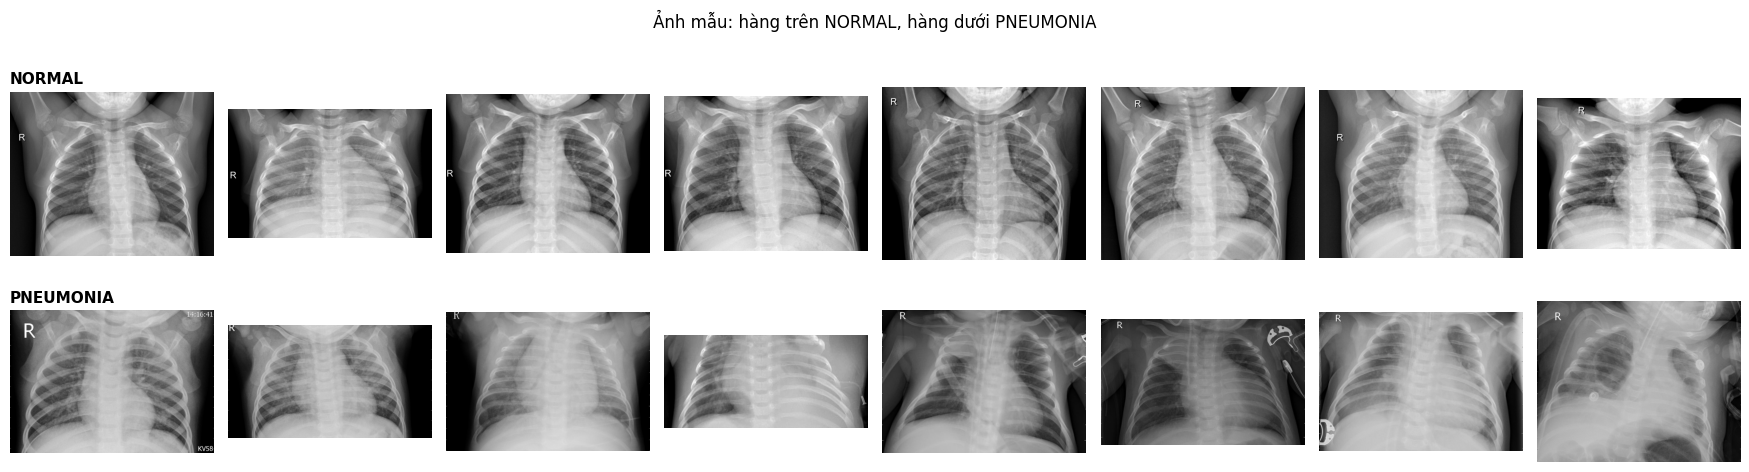

In [15]:
plot_samples(original["train"], 8, ROOT / "reports" / "sample_images.png")
plt.show()

## Bước 4 — `tf.data` pipeline
Resize 224×224, chuẩn hoá nằm trong model, augmentation **chỉ cho train** và **không lật ngang** (tim nằm bên trái — lật là sai giải phẫu).

In [16]:
train_ds = make_dataset(train_df, BATCH_SIZE, training=True)
val_ds = make_dataset(val_df, BATCH_SIZE)
test_ds = make_dataset(test_df, BATCH_SIZE)
y_val = val_df.label.to_numpy()
histories, rows = {}, []

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('converter', 'func'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('converter', 'func'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('converter', 'func'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimenta

## Bước 5 — Baseline: CNN nhỏ (3 khối Conv) huấn luyện từ đầu

In [17]:
baseline = build_baseline_cnn()
histories[STAGE_BASELINE] = train_stage(baseline, train_ds, val_ds, class_weight, EPOCHS_BASELINE, 1e-3, PATIENCE)
rows.append(validation_row(STAGE_BASELINE, y_val, predict_probs(baseline, val_ds), histories[STAGE_BASELINE]))
pd.DataFrame(rows)

Epoch 1/20
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000001D994019A20>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000001D994019A20>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. O

,Mô hình,AUC (val),Recall@0.5 (val),Specificity@0.5 (val),Accuracy@0.5 (val),Số epoch chạy
0,CNN từ đầu (baseline),0.9813,0.7336,1.0,0.8003,17


## Bước 6 — Transfer Learning giai đoạn 1 (EfficientNetB0, đóng băng backbone)

In [23]:
model = build_transfer_model()
histories[STAGE_FROZEN] = train_stage(model, train_ds, val_ds, class_weight, EPOCHS_FROZEN, 1e-3, PATIENCE)
rows.append(validation_row(STAGE_FROZEN, y_val, predict_probs(model, val_ds), histories[STAGE_FROZEN]))
frozen_weights = model.get_weights()
pd.DataFrame(rows)

16705208/16705208 [==============================] - 2s 0us/step
Epoch 1/10
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000001D99611A320>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000001D99611A320>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible,

,Mô hình,AUC (val),Recall@0.5 (val),Specificity@0.5 (val),Accuracy@0.5 (val),Số epoch chạy
0,CNN từ đầu (baseline),0.9813,0.7336,1.0000,0.8003,17
1,Transfer Learning (đóng băng),0.9898,0.8685,0.9845,0.8975,10


## Bước 7 — Fine-tuning giai đoạn 2
Mở khoá 30 tầng cuối của backbone (BatchNorm giữ đóng băng), learning rate **1e-5** (nhỏ hơn 100 lần). LR lớn sẽ phá huỷ tri thức ImageNet ngay trong vài bước đầu.

In [24]:
unfreeze_top_layers(model, 30)
histories[STAGE_FINETUNE] = train_stage(model, train_ds, val_ds, class_weight, EPOCHS_FINETUNE, 1e-5, PATIENCE)
rows.append(validation_row(STAGE_FINETUNE, y_val, predict_probs(model, val_ds), histories[STAGE_FINETUNE]))
pd.DataFrame(rows)

Epoch 1/20
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000001D992CD7760>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000001D992CD7760>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. O

,Mô hình,AUC (val),Recall@0.5 (val),Specificity@0.5 (val),Accuracy@0.5 (val),Số epoch chạy
0,CNN từ đầu (baseline),0.9813,0.7336,1.0000,0.8003,17
1,Transfer Learning (đóng băng),0.9898,0.8685,0.9845,0.8975,10
2,Fine-tuning (lr=1e-5),0.9931,0.8962,0.9845,0.9183,11


## Bước 8 — Learning curves, so sánh 3 cách tiếp cận, chọn model theo AUC validation

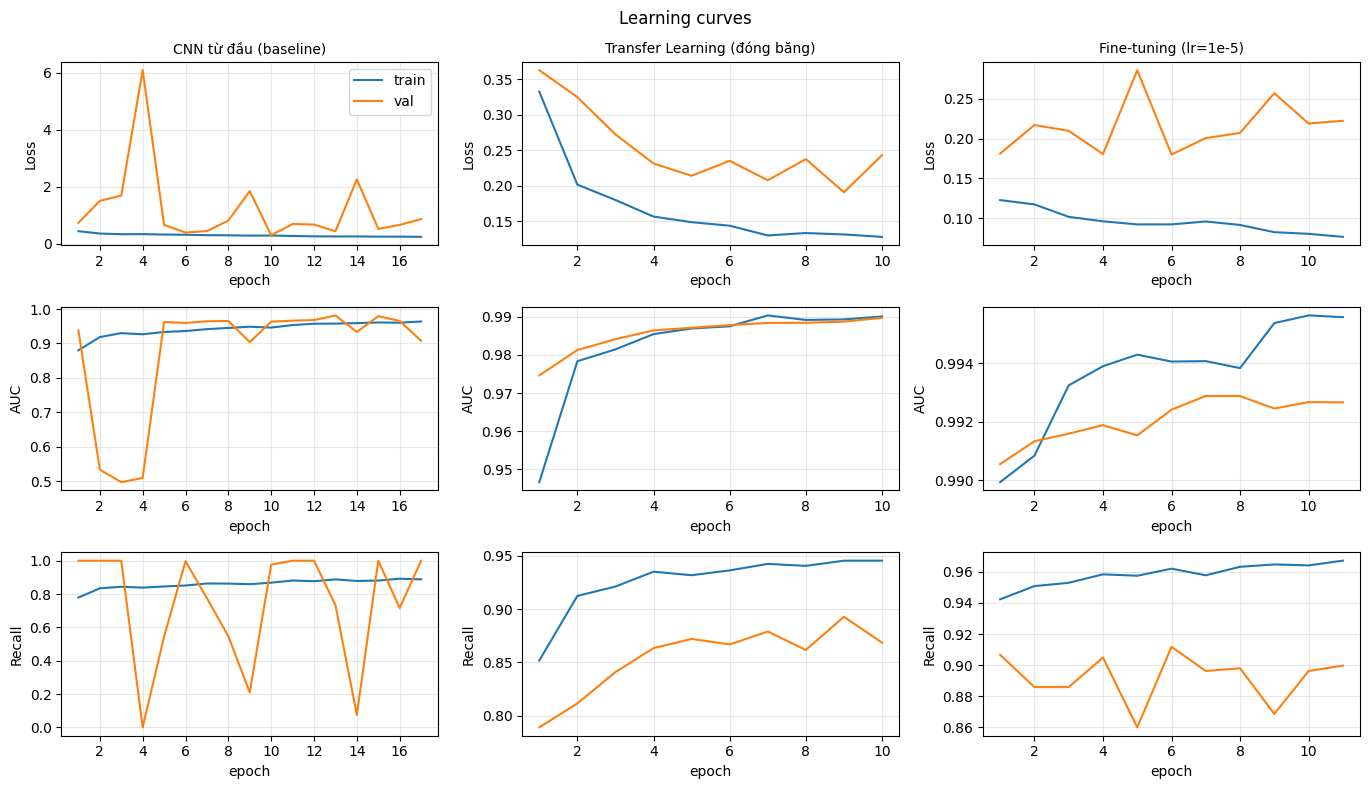

Model được chọn: Fine-tuning (lr=1e-5)


,Mô hình,AUC (val),Recall@0.5 (val),Specificity@0.5 (val),Accuracy@0.5 (val),Số epoch chạy
0,CNN từ đầu (baseline),0.9813,0.7336,1.0000,0.8003,17
1,Transfer Learning (đóng băng),0.9898,0.8685,0.9845,0.8975,10
2,Fine-tuning (lr=1e-5),0.9931,0.8962,0.9845,0.9183,11


In [26]:
import numpy as np

def fix_tensor_configs(m):
    for l in m.layers:
        if isinstance(l, tf.keras.layers.Rescaling):
            if hasattr(l.scale, "numpy"):
                l.scale = np.asarray(l.scale.numpy()).tolist()
            if hasattr(l.offset, "numpy"):
                l.offset = np.asarray(l.offset.numpy()).tolist()
        if hasattr(l, "layers"):  # backbone lồng nhau
            fix_tensor_configs(l)

plot_learning_curves(histories, ROOT / "reports" / "learning_curves.png")
plt.show()

comparison = pd.DataFrame(rows)
comparison.to_csv(ROOT / "reports" / "model_comparison.csv", index=False)
best_name = comparison.loc[comparison["AUC (val)"].idxmax(), "Mô hình"]
if best_name == STAGE_BASELINE:
    best_model = baseline
else:
    if best_name == STAGE_FROZEN:
        model.set_weights(frozen_weights)
    best_model = model

fix_tensor_configs(best_model)          # <-- thêm dòng này
best_model.save(ROOT / "models" / "best_model.keras")
best = tf.keras.models.load_model(ROOT / "models" / "best_model.keras", compile=False)
print("Model được chọn:", best_name)
comparison

## Bước 9 — Chọn ngưỡng đạt RECALL ≥ 0,97 trên tập **validation**

In [27]:
val_probs = predict_probs(best, val_ds)
thr = select_threshold(y_val, val_probs, TARGET_RECALL)
val_at_thr = compute_metrics(y_val, val_probs, thr)
print(f"Ngưỡng = {thr:.4f} | recall val = {val_at_thr['recall']:.4f} | specificity val = {val_at_thr['specificity']:.4f}")

Cause: Unable to locate the source code of <function Model.make_predict_function.<locals>.predict_function at 0x000001D995C33640>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function Model.make_predict_function.<locals>.predict_function at 0x000001D995C33640>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Orig

## Bước 10 — Đánh giá trên tập TEST (đúng 1 lần)
Ma trận nhầm lẫn và **số ca viêm phổi bị bỏ sót**. Accuracy thấp hơn recall là bình thường do phân phối test khác train.

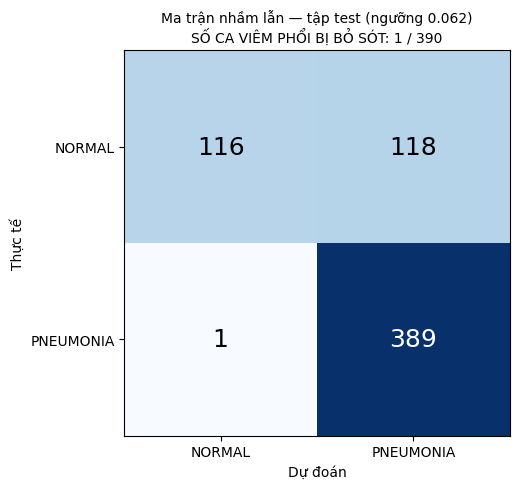

Recall test = 0.9974 | Accuracy = 0.8093 | AUC = 0.9637
SỐ CA VIÊM PHỔI BỊ BỎ SÓT: 1 / 390


In [28]:
y_test = test_df.label.to_numpy()
test_probs = predict_probs(best, test_ds)
test_at_thr = compute_metrics(y_test, test_probs, thr)
plot_confusion_matrix(test_at_thr, ROOT / "reports" / "confusion_matrix.png")
plt.show()
print(f"Recall test = {test_at_thr['recall']:.4f} | Accuracy = {test_at_thr['accuracy']:.4f} | AUC = {test_at_thr['auc']:.4f}")
print(f"SỐ CA VIÊM PHỔI BỊ BỎ SÓT: {test_at_thr['fn']} / {test_at_thr['fn'] + test_at_thr['tp']}")

## Bước 11 — Grad-CAM cho 6 ca
Model có nhìn vào **vùng phổi** không, hay nhìn vào chữ/nhãn ở góc phim (kiểu "gian lận")?

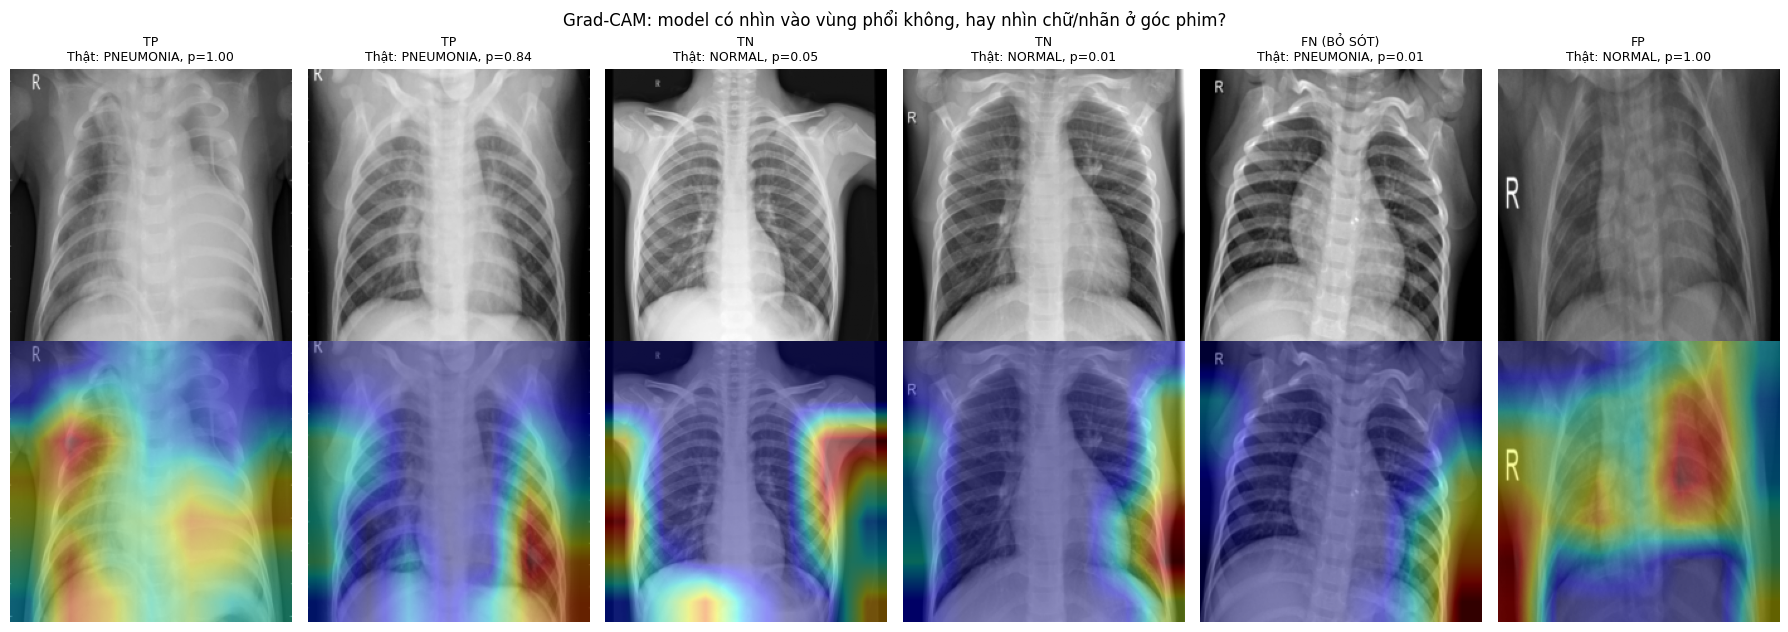

In [29]:
plot_gradcam_examples(best, test_df, test_probs, thr, 6, ROOT / "reports" / "gradcam_examples.png")
plt.show()

## Bước 12 — 10 ca dự đoán sai

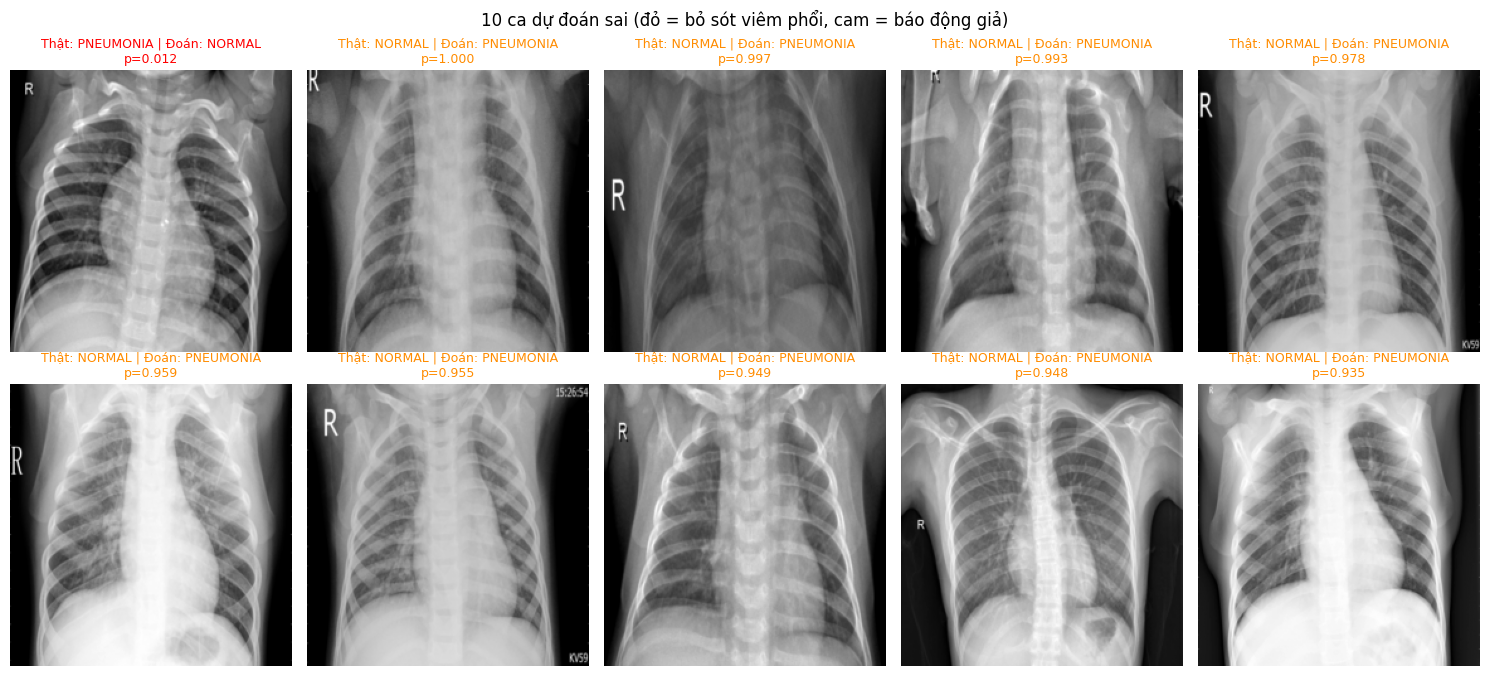

In [30]:
plot_errors(test_df, test_probs, thr, 10, ROOT / "reports" / "ca_du_doan_sai.png")
plt.show()

## Nhận xét (điền sau khi xem kết quả)
- **So sánh 3 cách tiếp cận:** …
- **Grad-CAM:** model có tập trung vào vùng phổi không? Có ca nào chú ý vào chữ/nhãn/góc phim?
- **Phân tích ca sai:** các ca bỏ sót có đặc điểm chung gì (mờ, viêm phổi virus, phim chụp lệch…)?
- **Giới hạn:** dữ liệu 1 bệnh viện nhi, 1–5 tuổi; test phân phối khác train; chưa kiểm định bên ngoài.

> ⚖️ Nhắc lại: công cụ sắp thứ tự ưu tiên đọc phim, không thay thế bác sĩ.